In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


In [2]:
class ImitationAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ImitationAgent, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


In [3]:
env = gym.make("CartPole-v1")
expert_data = []
episodes = 50

for ep in range(episodes):
    state, _ = env.reset()
    for t in range(200):
        # Expert rule: push right if pole leans right
        action = 1 if state[2] > 0 else 0
        next_state, reward, done, truncated, _ = env.step(action)
        expert_data.append((state, action))
        state = next_state
        if done or truncated:
            break

states = torch.tensor([s for s, _ in expert_data], dtype=torch.float32)
actions = torch.tensor([a for _, a in expert_data], dtype=torch.long)


/tmp/ipython-input-2745725227.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor([s for s, _ in expert_data], dtype=torch.float32)


In [4]:
agent = ImitationAgent(state_dim=4, action_dim=2)
optimizer = optim.Adam(agent.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    logits = agent(states)
    loss = criterion(logits, actions)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Training complete. Agent has learned to imitate the expert.")


Training complete. Agent has learned to imitate the expert.


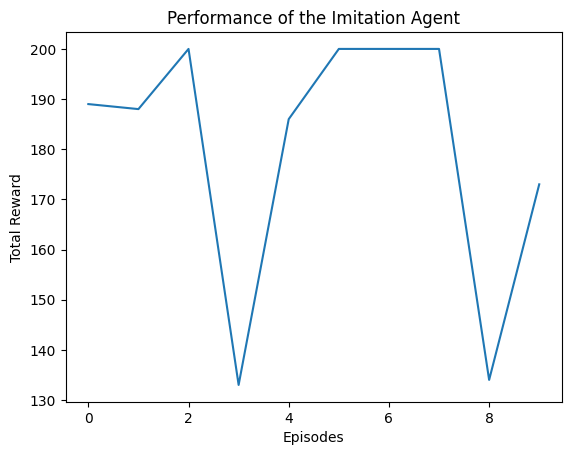

In [5]:
rewards = []
for ep in range(10):
    state, _ = env.reset()
    total_reward = 0
    for t in range(200):
        with torch.no_grad():
            probs = agent(torch.tensor(state, dtype=torch.float32))
            action = torch.argmax(probs).item()
        next_state, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        state = next_state
        if done or truncated:
            break
    rewards.append(total_reward)

plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Performance of the Imitation Agent")
plt.show()
